In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
import xgboost as xgb

import pyswarms as ps

In [5]:
df = pd.read_csv("SOC_dataset.csv")
print("Dataset shape:", df.shape)

Dataset shape: (6542, 22)


In [6]:
df.head()

,Red,Green,Blue,NIR,RedEdge,NDVI,GNDVI,NDRE,EVI,SAVI,...,OSAVI,ARVI,MSAVI,Altitude,Slope,Aspect,Relief,SOA,SOS,SOC
0,0.287270,0.583664,0.129517,0.410369,0.418197,0.176450,-0.174336,-0.009448,0.142303,0.154177,...,0.143532,-0.031096,0.147103,18.555842,2.298824,221.017516,2.008601,9.271774,1.066951,3.373235
1,0.575357,0.234299,0.051436,0.704526,0.375171,0.100922,0.500867,0.305044,0.067686,0.108857,...,0.089708,-0.207037,0.112489,2.473981,10.934824,218.514483,2.959071,0.331240,7.984612,1.700179
2,0.465997,0.347413,0.170027,0.711742,0.243089,0.208658,0.343981,0.490822,0.190057,0.219711,...,0.183702,-0.027691,0.223395,5.079005,6.922922,201.354483,8.372263,5.960393,4.608471,2.622817
3,0.399329,0.143058,0.389101,0.691506,0.292967,0.267847,0.657167,0.404824,0.624723,0.275494,...,0.233585,0.150031,0.277540,5.244453,0.506519,296.145269,8.104629,4.091275,0.326308,5.200297
4,0.178009,0.379568,0.293239,0.549361,0.294751,0.510540,0.182783,0.301631,2.220326,0.453838,...,0.418485,0.405952,0.450650,11.418658,3.517373,292.542413,8.950733,4.295787,2.238265,5.836115


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6542 entries, 0 to 6541
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Red       6542 non-null   float64
 1   Green     6542 non-null   float64
 2   Blue      6542 non-null   float64
 3   NIR       6542 non-null   float64
 4   RedEdge   6542 non-null   float64
 5   NDVI      6542 non-null   float64
 6   GNDVI     6542 non-null   float64
 7   NDRE      6542 non-null   float64
 8   EVI       6542 non-null   float64
 9   SAVI      6542 non-null   float64
 10  DVI       6542 non-null   float64
 11  RVI       6542 non-null   float64
 12  OSAVI     6542 non-null   float64
 13  ARVI      6542 non-null   float64
 14  MSAVI     6542 non-null   float64
 15  Altitude  6542 non-null   float64
 16  Slope     6542 non-null   float64
 17  Aspect    6542 non-null   float64
 18  Relief    6542 non-null   float64
 19  SOA       6542 non-null   float64
 20  SOS       6542 non-null   floa

In [8]:
X = df.drop(columns=['SOC'])
y = df['SOC']

In [9]:
# Scaling numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

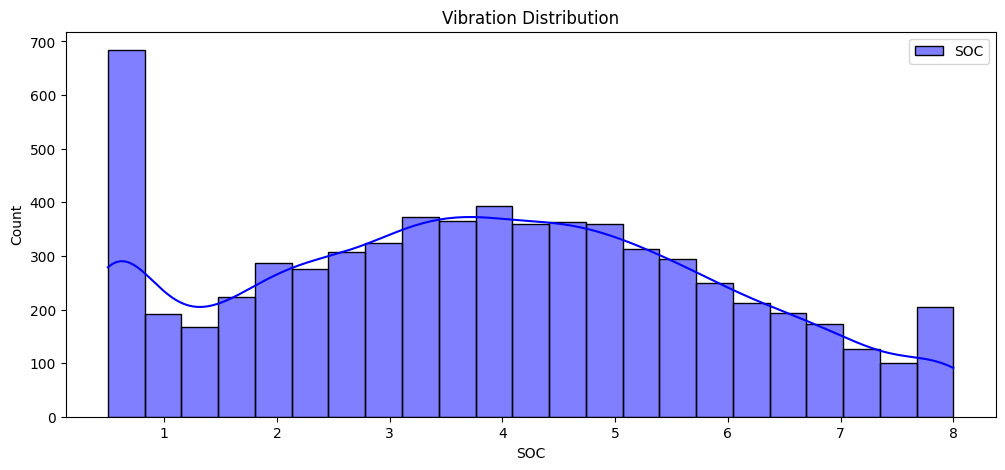

In [11]:
plt.figure(figsize=(12,5))
sns.histplot(y, color='blue', kde=True, label='SOC')
plt.title("Vibration Distribution")
plt.legend()
plt.show()

In [12]:
def fitness_function(features_mask):
    """
    Fitness function for PSO (minimize RMSE of XGBoost using selected features)
    features_mask: [n_particles, n_features]
    """
    n_particles = features_mask.shape[0]
    scores = []
    
    for i in range(n_particles):
        mask = features_mask[i] > 0.5
        if np.sum(mask) == 0:
            scores.append(1e6)
            continue
        X_masked = X_scaled[:, mask]
        X_train, X_val, y_train, y_val = train_test_split(X_masked, y, test_size=0.2, random_state=42)
        model = xgb.XGBRegressor(max_depth=4,
                                 min_child_weight=3,
                                 learning_rate=0.25,
                                 n_estimators=128,
                                 reg_alpha=0.6,
                                 reg_lambda=0.8,
                                 verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        scores.append(rmse)
    return np.array(scores)

In [13]:
import pyswarms as ps

n_features = X_scaled.shape[1]

options = {
    'c1': 0.5,
    'c2': 0.3,
    'w': 0.9,
    'k': 3,   # required by PySwarms, ignored for global topology
    'p': 2  # required by PySwarms, ignored for global topology
}

optimizer = ps.discrete.BinaryPSO(
    n_particles=10,
    dimensions=n_features,
    options=options
)

best_cost, best_pos = optimizer.optimize(fitness_function, iters=5)
selected_features = X.columns[best_pos > 0.5]

2026-03-15 21:17:03,018 - pyswarms.discrete.binary - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 3, 'p': 2}
pyswarms.discrete.binary: 100%|███████████████████████████████████████████████████████████████████|5/5, best_cost=0.358
2026-03-15 21:17:07,612 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.3580540034858798, best pos: [0 1 0 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 1]


In [14]:
print("Selected features by PSO:", selected_features.tolist())

Selected features by PSO: ['Green', 'RedEdge', 'NDVI', 'GNDVI', 'NDRE', 'EVI', 'SAVI', 'DVI', 'MSAVI', 'Altitude', 'Slope', 'Aspect', 'Relief', 'SOS']


In [15]:
df_pro = df[['Green', 'RedEdge', 'NDVI', 'GNDVI', 'NDRE', 'EVI', 'SAVI', 'DVI', 'MSAVI', 'Altitude', 'Slope', 'Aspect', 'Relief', 'SOS','SOC']]

In [16]:
df_pro.to_csv('processed.csv')

In [17]:
X = df_pro[['Green', 'RedEdge', 'NDVI', 'GNDVI', 'NDRE', 'EVI', 'SAVI', 'DVI', 'MSAVI', 'Altitude', 'Slope', 'Aspect', 'Relief', 'SOS']]
y = df_pro["SOC"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5233, 14), (1309, 14), (5233,), (1309,))

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

ML_Model = []
mape = []
rmse = []
mae = []
r2 = []

def storeResults(model, a, b, c, d):
    ML_Model.append(model) 
    mape.append(round(a, 3)) 
    rmse.append(round(b, 3))
    mae.append(round(c, 3))
    r2.append(round(d, 3))

# XGBoost

In [20]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    max_depth=4,
    min_child_weight=3,
    learning_rate=0.25,
    n_estimators=128,
    reg_alpha=0.6,
    reg_lambda=0.8,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [21]:
xgb_mape = mean_absolute_percentage_error(y_test, y_pred)
xgb_rmse = mean_squared_error(y_test, y_pred, squared=False)
xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_r2 = r2_score(y_test, y_pred)

In [23]:
storeResults("XGBoost", xgb_mape, xgb_rmse, xgb_mae, xgb_r2)

# SVM

In [24]:
from sklearn.svm import LinearSVR
svm_model = LinearSVR(C=1.0, max_iter=100)
svm_model.fit(X_train, y_train)

LinearSVR(max_iter=100)

In [25]:
y_pred = svm_model.predict(X_test)

svm_mape = mean_absolute_percentage_error(y_test, y_pred)
svm_rmse = mean_squared_error(y_test, y_pred, squared=False)
svm_mae = mean_absolute_error(y_test, y_pred)
svm_r2 = r2_score(y_test, y_pred)

In [26]:
storeResults("SVM", svm_mape, svm_rmse, svm_mae, svm_r2)

# Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor
gpr = RandomForestRegressor()
gpr.fit(X_train, y_train)

RandomForestRegressor()

In [29]:
y_pred = gpr.predict(X_test)

gp_mape = mean_absolute_percentage_error(y_test, y_pred)
gp_rmse = mean_squared_error(y_test, y_pred, squared=False)
gp_mae = mean_absolute_error(y_test, y_pred)
gp_r2 = r2_score(y_test, y_pred)

In [30]:
storeResults("Random Forest", gp_mape, gp_rmse, gp_mae, gp_r2)

# Ensemble Model

In [31]:
from sklearn.ensemble import GradientBoostingRegressor,  VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [32]:
xgb = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

gbr = GradientBoostingRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

lgbm = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

cat = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)

voting = VotingRegressor(
    estimators=[
        ('xgb', xgb),
        ('gbr', gbr),
        ('lgbm', lgbm),
        ('cat', cat)
    ],
    weights=[3, 1, 3, 2]
)

voting.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 5233, number of used features: 14
[LightGBM] [Info] Start training from score 3.831638


VotingRegressor(estimators=[('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          num_parallel_tree=None,
                                          random_state=42, ...)),
       

In [33]:
y_pred = voting.predict(X_test)

vr_mape = mean_absolute_percentage_error(y_test, y_pred)
vr_rmse = mean_squared_error(y_test, y_pred, squared=False)
vr_mae = mean_absolute_error(y_test, y_pred)
vr_r2 = r2_score(y_test, y_pred)

In [35]:
storeResults("VotingRegressor", vr_mape, vr_rmse, vr_mae, vr_r2)

# Comparison

In [36]:
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'MAPE' : mape,
                        'RMSE': rmse,
                        'MAE'   : mae,
                        'R2-Score': r2                        
                      })

In [37]:
result

,ML Model,MAPE,RMSE,MAE,R2-Score
0,XGBoost,0.131,0.358,0.285,0.969
1,SVM,0.423,2.082,0.888,-0.047
2,Random Forest,0.136,0.393,0.307,0.963
3,VotingRegressor,0.116,0.320,0.255,0.975


# Modelling

In [38]:
import joblib

joblib.dump(voting, "model.sav")

['model.sav']

# Graph

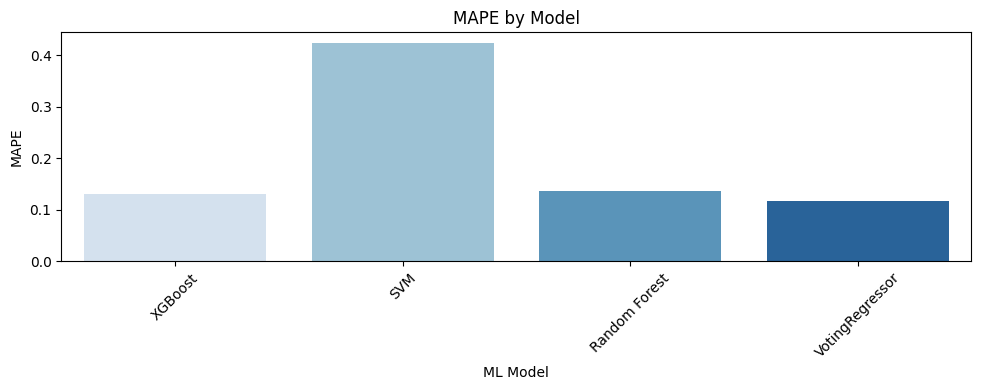

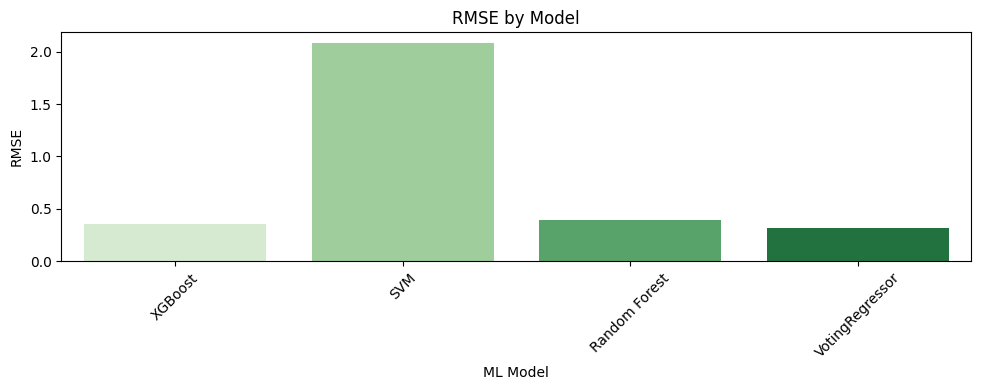

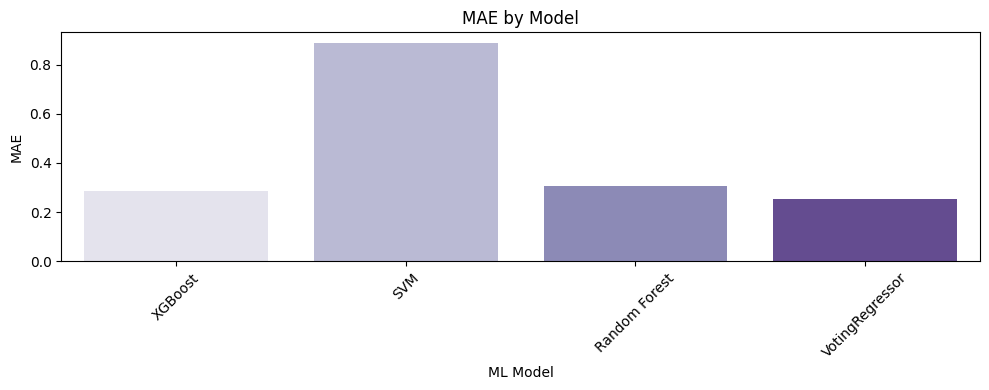

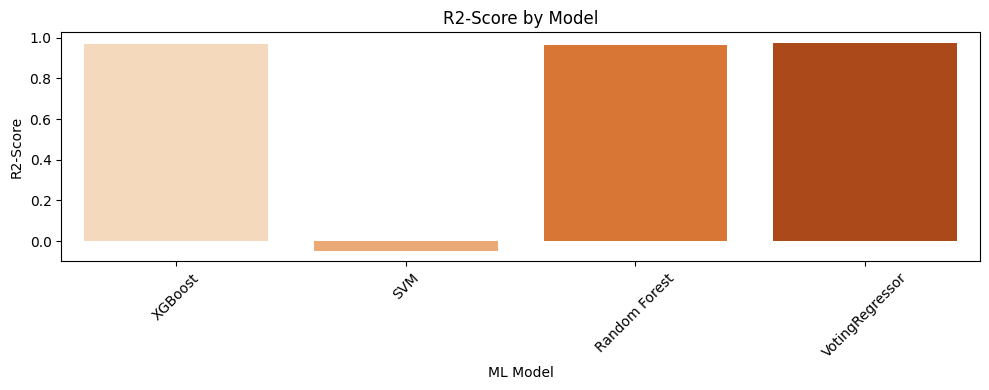

In [39]:
palettes = {
    'MAPE': 'Blues',
    'RMSE': 'Greens',
    'MAE': 'Purples',
    'R2-Score': 'Oranges'
}

for metric in ['MAPE', 'RMSE', 'MAE', 'R2-Score']:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=result, x='ML Model', y=metric, palette=palettes[metric])
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()